# - Dimensionality reduction Techinque

---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/Wine.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Customer_Segment      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [ ]:
df['Customer_Segment'].value_counts()

,count
Customer_Segment,
2,71
1,59
3,48


In [44]:
from scipy.stats import f_oneway

def checkAnova(df,cat,num):
  p = f_oneway(*df.groupby(cat)[num].apply(list))[1]

  if p>0.05 : print(f"no correlation between {cat} and {num}")
  else: print(f"Relation is in {cat} and {num}")

In [45]:
for col in df.columns:
  if df[col].dtype == 'int64' or df[col].dtype=='float64':
    checkAnova(df,'Customer_Segment',col)

no correlation between Customer_Segment and Alcohol
no correlation between Customer_Segment and Malic_Acid
no correlation between Customer_Segment and Ash
Relation is in Customer_Segment and Ash_Alcanity
no correlation between Customer_Segment and Magnesium
Relation is in Customer_Segment and Total_Phenols
Relation is in Customer_Segment and Flavanoids
Relation is in Customer_Segment and Nonflavanoid_Phenols
Relation is in Customer_Segment and Proanthocyanins
no correlation between Customer_Segment and Color_Intensity
Relation is in Customer_Segment and Hue
Relation is in Customer_Segment and OD280
Relation is in Customer_Segment and Proline
Relation is in Customer_Segment and Customer_Segment


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
df['Proline'] = sc.fit_transform(df[['Proline']])
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1.013009,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,0.965242,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1.395148,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,2.334574,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,-0.037874,1


In [ ]:
from sklearn.decomposition import PCA

x = df.drop('Customer_Segment',axis=1)

pca = PCA(n_components=2)
xpca = pca.fit_transform(x)
xpca.shape

(178, 2)

In [ ]:
pca.components_

array([[ 1.57228956e-02, -4.35760133e-03,  5.48180679e-03,
        -2.09367676e-02,  9.98488706e-01,  9.53949567e-03,
         1.39003897e-02, -2.24776190e-03,  9.55487541e-03,
         3.32956286e-02,  8.83280590e-04,  3.33012153e-03,
         2.80119168e-02],
       [-6.96422556e-02,  1.12479209e-01,  3.60823752e-02,
         9.66169981e-01,  2.65428779e-02, -6.86212981e-02,
        -1.21640793e-01,  1.37852324e-02, -3.83655760e-02,
         5.36135499e-02, -2.24695619e-02, -7.30292777e-02,
        -1.30872477e-01]])

- it shows 1.57... value is added to 1st column,

    -4.357... added to 2nd column

- and so on..

- to reduce the 13 columns into 1st column

- same with 2nd one.

In [ ]:
pca.components_.shape

(2, 13)

In [ ]:
pca.explained_variance_ratio_

array([0.90609434, 0.05190292])

In [ ]:
pca.inverse_transform(xpca).shape

(178, 13)

In [ ]:
np.cumsum(pca.explained_variance_ratio_)

array([0.90609434, 0.95799726])

In [ ]:
pca.inverse_transform(xpca)[:1]

array([[ 13.68074798,   1.81425585,   2.38753318,  15.46221763,
        127.0045107 ,   2.80216584,   2.84562877,   0.25091291,
          1.99005253,   5.7784226 ,   1.06209607,   2.96438731,
          1.2360573 ]])

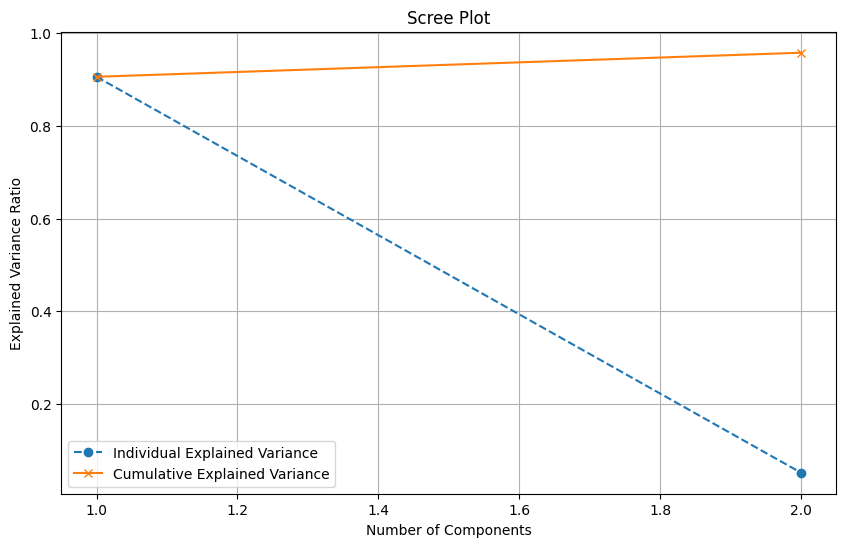

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='x', linestyle='-')
plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.legend(['Individual Explained Variance', 'Cumulative Explained Variance'])
plt.show()